In [33]:
import os
import neurovoc
import tempfile
import librosa

import numpy as np
import matplotlib.pyplot as plt
import scipy
from IPython.display import Audio

In [38]:
n_fft = 512
hops = 32

## Helper functions

### Plot spectrogram

In [ ]:
def get_spectrogram(y, sr, n_fft, hops):
    S = librosa.feature.melspectrogram(
        y=y, 
        sr=sr, 
        n_mels=64, 
        fmin=150, 
        fmax=10_500,
        n_fft=n_fft, 
        hop_length=hops
    )

    S_dB = librosa.power_to_db(S, ref=np.max)
    return S_dB

data_path = "../data"
n_mels = 64
min_freq = 150
max_freq = 10_500
mel_scale = librosa.filters.mel_frequencies(n_mels, fmin=min_freq, fmax=max_freq)

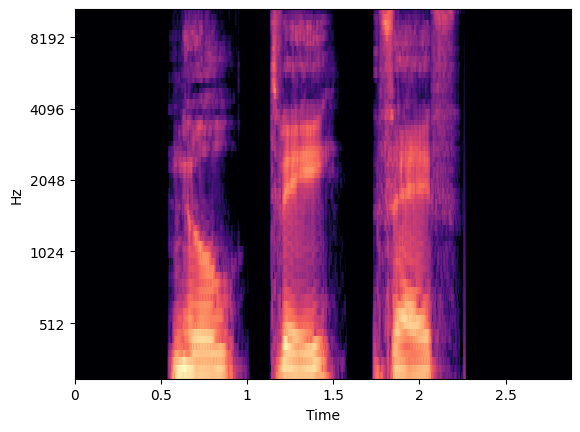

In [ ]:
filename = "../data/din/triplets/025.wav"
y, sr = librosa.load(filename)


S_db = get_spectrogram(y, sr, n_fft, hops)
librosa.display.specshow(S_db, x_axis='time',
                         y_axis='mel', sr=sr,
                          fmin=150, fmax=10_500, 
                         n_fft=n_fft, hop_length=hops)

### Plot Spectrogram with Neurogram

In [24]:
def plot_spectr_vs_neurogram(S_db, neurogram_specres, sr, hops, soundname="sound"):
    fig = plt.figure(figsize=(8, 4))
    gs = fig.add_gridspec(2, 2,  height_ratios=[1, 2])

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(np.arange(len(y)) * (1/sr), y, label=soundname, color='#4682B4', linewidth=4)
    ax1.plot(np.arange(len(y)) * (1/sr), y, color='white', linewidth=.05)
    ax1.grid()
    ax1.legend()

    ax2 = fig.add_subplot(gs[1, 0])
    t = np.arange(S_db.shape[1]) * hops * (1 / sr)
    cmap = 'cividis'

    ax2.pcolormesh(
        t, neurogram_specres.frequencies, S_db, cmap=cmap
    )

    ax3 = fig.add_subplot(gs[1, 1], sharex=ax2, sharey=ax2)

    sp_data_phast = np.vstack(
        [
            scipy.signal.resample(neurogram_specres.data[i], S_db.shape[1])
            for i in range(neurogram_specres.data.shape[0])
        ]
    )

    img = ax3.pcolormesh(
        t, neurogram_specres.frequencies, sp_data_phast, cmap=cmap
    )


    ax2.set_title("Spectogram")
    ax3.set_title("Neurogram")

    ax2.set_ylabel("[Hz]")
    ax2.set_yscale("log", base=2)
    ax2.set_yticks([pow(2, i) for i in range(9, 14)], [pow(2, i) for i in range(9, 14)])
    ax2.set_ylim(500, None)
    ax2.set_xlim(0, np.max(t))

    # ax1.set_ylabel("amplitude")
    ax3.set_ylabel("[Hz]")

    for ax in ax2, ax3:
        ax.set_xlabel("Time [s]")
    plt.tight_layout()


Neurogram(dt=3.6e-05, source='phast_specres', shape=(64, 79924))


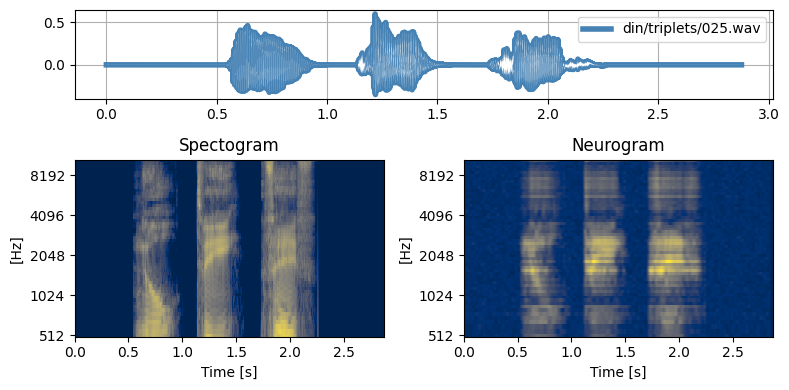

In [ ]:
#root = os.path.dirname(os.path.dirname(__file__))
root = "../data"
soundname = "din/triplets/025.wav"
filename = os.path.join(root, soundname)

#y, sr = librosa.load(librosa.ex('robin'))
y, sr = librosa.load(filename)

S_db = get_spectrogram(y, sr, n_fft, hops)

neurogram_specres = neurovoc.specres(filename, n_trials=1)
        
print(neurogram_specres)            

plot_spectr_vs_neurogram(S_db, neurogram_specres, sr, hops, soundname)

Neurogram(dt=3.6e-05, source='phast_specres', shape=(64, 371260))


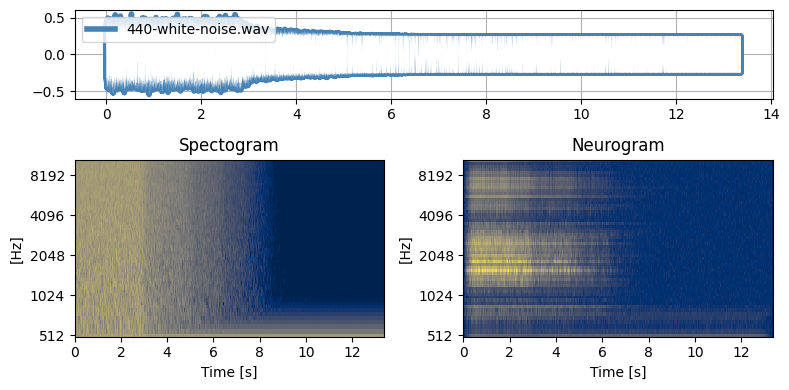

In [ ]:
soundname_noise = "440-white-noise.wav"
filename_noise = os.path.join(root, soundname)

#y, sr = librosa.load(librosa.ex('robin'))
y, sr = librosa.load(filename_noise)
S_db_noise = get_spectrogram(y, sr, n_fft, hops)

neurogram_specres = neurovoc.specres(filename, n_trials=1)
        
print(neurogram_specres)            

plot_spectr_vs_neurogram(S_db, neurogram_specres, sr, hops, soundname)

### Helper plot and play reconstructed

In [36]:
def plot_and_play_reconstructed(original, reconstructed, fs):
    f, axes = plt.subplots(2, 2, sharey="row", sharex=True, figsize=(13, 5), height_ratios=[1, 3])

    m = 2
    # fs = 16000  * m
    cmap = 'cividis'

    for ((ax1, ax2), y, title) in zip(axes.T, (original, reconstructed), ("Choice", "EH Vocoded")):
        # y = librosa.resample(y.copy(), orig_sr=16000, target_sr=fs)
        t_sound = np.arange(len(y)) / fs   
        ax1.plot(t_sound, y, color='#4682B4', linewidth=4)
        ax1.plot(t_sound, y, color='white', linewidth=.05)
        spectrogram = get_spectrogram(y, fs, n_fft * m, hops * m)
        t_spec = np.arange(spectrogram.shape[1]) * hops*m * (1 / fs)
        ax2.pcolormesh(t_spec, mel_scale, spectrogram, vmin=-80, vmax=0, cmap=cmap)
        ax1.set_title(title, fontsize=16)
        ax1.set_yticks([-.5, .5], [-.5, .5], fontsize=14)
        ax2.set_xlabel("Time [s]", fontsize=15)
        ax2.tick_params(axis='both', which='major', labelsize=14)
        ax1.grid()
        display(Audio(data=y, rate=fs, element_id=title))


    axes[0][0].set_ylabel("Ampl.", fontsize=15)
    ax2 = axes[1][0]
    ax2.set_ylabel("Frequency [Hz]",  fontsize=15)
    ax2.set_yscale("log", base=2)
    ax2.set_yticks([pow(2, i) for i in range(8, 14)], [pow(2, i) for i in range(8, 14)], fontsize=14)
    ax2.set_ylim(min_freq, 8200)
    ax2.set_xlim(0, np.max(t))

    for ax, label in zip(axes.ravel(), "ABCDEF"):
        ax.text(0.95, 0.95, label,
            transform=ax.transAxes,
            fontsize=15, fontweight='bold',
            va='top', ha='right',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.15'))

    plt.tight_layout()
    # plt.savefig("choice_no_noise.png", dpi=600)

## Reconstruct

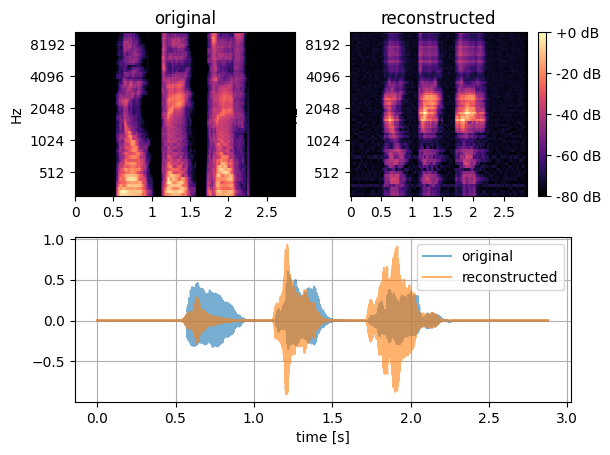

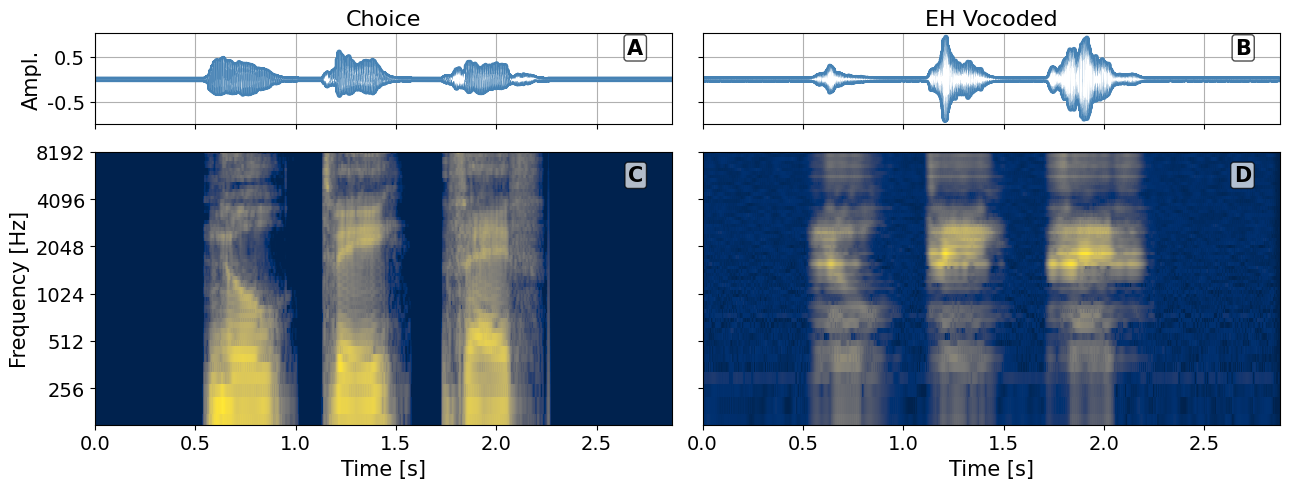

In [37]:
reconstructed = neurovoc.reconstruct(neurogram_specres)
original, fs = librosa.load(filename, sr=None)
reconstructed = scipy.signal.resample(reconstructed, original.size)

neurovoc.audio_vs_reconstructed(
    original,
    reconstructed,
    fs,
    len(neurogram_specres.frequencies),
    neurogram_specres.min_freq, 
    neurogram_specres.max_freq, 
)
plt.show()

plot_and_play_reconstructed(original, reconstructed, fs)